# OccPy tutorial notebook for Terrestrial Laser Scanning (TLS) data - Individual OccPy Run per LAZ file

This is basically the same notebook as [TLS_notebook.ipynb], however, each input laz file is treated individually, instead of passing the input folder to OccPy and let OccPy treat the input. Treating laz files individually can be beneficial from a performance perspective and it can further introduce an increased amount of flexibility for linking scan position to the specific laz point cloud. The process though, is roughly the same.

First we download the test data and look for the OccPy root folder on your system. All following paths depend on this root directory. 
We further have a look into the JSON settings file to look at its structure

In [1]:
import json
import os
from pathlib import Path
import pooch

# get OccPy root directory
def find_project_root(markers=('README.md','.gitignore','environment.yml','setup.py')):
    try:
        import ipynbname
        current = ipynbname.path().parent
    except Exception:
        current = Path(os.getcwd())

    for parent in [current, *current.parents]:
        if any((parent / m).exists() for m in markers):
            return parent
        
    return current # fallback if nothing found

# Download test data
p = pooch.Pooch(base_url="doi:10.5281/zenodo.17750604/", path=pooch.os_cache("occpy_test_data"))
p.load_registry_from_doi()
p.fetch("TLS_demo.zip", processor=pooch.Unzip(members=["TLS_demo"]), progressbar=True)
data_path = os.path.join(p.path, "TLS_demo.zip.unzip", "TLS_demo")
print(data_path)

occpy_root = find_project_root()
print("Detected occpy root:", occpy_root)

# Load the JSON file
with open(os.path.join(occpy_root, 'config', 'settings_TLS_tutorial.JSON'), 'r') as file:
    settings_orig = json.load(file)
# Display the settings
settings_orig

C:\Users\Kueken\AppData\Local\occpy_test_data\occpy_test_data\Cache\TLS_demo.zip.unzip\TLS_demo
Detected occpy root: c:\Users\Kueken\dev\occpy_dev\OccPy


{'root_folder': '',
 'laz_in': 'data/TLS/LAZ/',
 'tif_in': {'DTM': 'data/Grids/Ramerenwald_DTM_20250305.tif',
  'DSM': 'data/Grids/Ramerenwald_DSM_20250305.tif'},
 'out_dir': 'output/TLS',
 'vox_dim': 0.1,
 'lower_threshold': 1,
 'points_per_iter': 1000000,
 'plot_dim': [2676515, 1246063, 545, 2676525, 1246113, 590],
 'ScanPos': 'data/TLS/ScanPositions.txt',
 'output_voxels': False}

This JSON file can either be modified using your text editor of choice or you could load it into python using the json package and alter the variables within the script, as shown in the following code snippet.
Here is an explanation for the various settings:
- root_folder: root folder of where OccPy is installed -> actually not necessary anymore and can be blank
- laz_in: input laz file - In this case we are expecting a single laz file. If you have multiple laz file (e.g. when using multiple TLS scans), this could be also a directory. See TLS_notebook.ipynb notebook for this case
- tif_in[DTM]: Optional input defining a digital terrain model as a tif file. This is used later for normalization of the output
- tif_in[DSM]: Optional input defining a digital surface model as a tifl file. This is only used in order to give a restriction, until where the canopy is going and will cut off everything above. If this is not needed, you can leave this specification empty. 
        For both surface models: if the extent and resolution does not match the provided plot_dim, it will be cut and transformed to match the voxel grid dimension. It would also expand the terrain/surface models, but I would recommend to always provide a terrain/surface model that is larger in extent than the defined plot_dim
- out_dir: output directory where the output .npy files are stored
- vox_din: voxel size - currently this applies to x, y, and z dimension. Non-cubic voxels are on the list of features to be added
- lower_threshold: height, below which the output will be cut. This can be used to get rid of ground effect on the outputs. 
- points_per_iter: how many points should be loaded in one go. 
- plot_dim: plot dimensions in the format [min_x, min_y, min_z, max_x, max_y, max_z]
- ScanPos: path to the trajectory information (or scan position information for TLS)
- output_voxels: [True/False] if the output should be outputted as ply files - currently not working properly.

In [2]:
import json
import os

# copy original settings file 
settings = settings_orig.copy()
# alter root folder
settings['root_folder'] = os.path.abspath(occpy_root)
# update input paths to be relative to the root folder
settings['laz_in'] = os.path.join(data_path, 'LAZ')
settings['tif_in']['DTM'] = os.path.join(data_path, 'Grids', 'Ramerenwald_DTM_20250305.tif')
settings['tif_in']['DSM'] = os.path.join(data_path, 'Grids', 'Ramerenwald_DSM_20250305.tif')
settings['ScanPos'] = os.path.join(data_path, 'ScanPos', 'ScanPositions.txt')
settings['out_dir'] = os.path.join(settings['root_folder'], 'output', 'TLS')


# Save the modified settings back to the JSON file
with open(os.path.join(occpy_root, 'config', 'settings_TLS_tutorial_out_indivLAZ.JSON'), 'w') as file:
    json.dump(settings, file, indent=4)


Not necessary, but if you already adapted the json file in a text editor, you can load it here and skip the above step.

In [3]:
def load_config(config_file):
    """Load the configuration from the JSON file."""
    with open(config_file, 'r') as file:
        config = json.load(file)
    return config

config_file = os.path.join(occpy_root, 'config', 'settings_TLS_tutorial_out_indivLAZ.JSON')
config = load_config(config_file)

Now we load the necessary occPy package. If you get a message like "RIEGL RDBlib is not available", this can be ignored, as this is only relevant if you work directly with the RIEGL output files.

In [4]:
from occpy.OccPy import OccPy
from occpy.OccPy import read_sensorpos_file

Let's load the sensor position information. It is important that the point cloud data (LAZ file) can be directly linked to the scan position information. In this case, we expect that the scan position identifier is stated in the laz file name (ScanPos033_sort_filtered.laz). In the following cells, we will be looking for the scan position entry in ScanPositions.txt with the value 33 in the 'ScanPos' column.

In [5]:
sens_pos = read_sensorpos_file(config['ScanPos'],                       # Path to the sensor position file
                               delimiter=",",                           # Delimiter used in the file (e.g., comma, tab)
                               hdr_scanpos_id="ID",                     # Header name for the scan position ID column
                               hdr_x='X',                               # Header name for the X coordinate column
                               hdr_y='Y',                               # Header name for the Y coordinate column
                               hdr_z='Z',                               # Header name for the Z coordinate column
                               sens_pos_id_offset=0)                    # Offset to be added to the scan position IDs (if needed, i.e. if the IDs in the ScanPos file is not matching the LAZ file names)

Now we get all laz file within the input laz folder and iterate over each laz file, match it to the sensor position and run the voxel traversal

In [6]:
import glob

# get all laz files in the input folder
laz_files = glob.glob(os.path.join(config['laz_in'], '*.laz'))

for laz_in in laz_files:
    scan_name = os.path.basename(laz_in)

    print(f"Processing {scan_name}...")

    # create instance of OccPy
    occpy = OccPy(laz_in=laz_in,                                            # Path to the input LAZ file     
                  out_dir=f"{config['out_dir']}\\{scan_name[:-4]}",         # Path to the output directory, we create a subfolder for each scan, for this we get rid of the .laz ending from scan_name
                  vox_dim=config['vox_dim'],                                # Voxel dimension in meters
                  lower_threshold=config['lower_threshold'],                # Lower threshold for the number of points in a voxel to be considered occupied
                  points_per_iter=config['points_per_iter'],                # Number of points to process in each iteration
                  plot_dim=config['plot_dim'],                              # Dimension of the area to plot around each scan position (in meters)
                  output_voxels=config['output_voxels'])                    # currently not in use
    
    # get sensor position for input laz
    scan_id = int(scan_name[7:10])              # note: this is very specific and has to be adapted to the specific naming convention of the laz files
                                                # in this case we assume the scan name is like "ScanPos033_sort_filtered.laz", so we extract the 033 part and convert it to an integer
    scanpos_X = sens_pos.loc[sens_pos['ScanPos'] == scan_id, 'sensor_x'].values[0]
    scanpos_Y = sens_pos.loc[sens_pos['ScanPos'] == scan_id, 'sensor_y'].values[0]
    scanpos_Z = sens_pos.loc[sens_pos['ScanPos'] == scan_id, 'sensor_z'].values[0]

    occpy.define_sensor_pos_singlePos(scan_pos_id=scan_id,
                                     x= scanpos_X,
                                     y= scanpos_Y,
                                     z= scanpos_Z)

    occpy.do_raytracing()

Processing ScanPos033_sort_filtered.laz...


Tracing Pulses...: 100%|██████████| 4623932/4623932 [00:24<00:00, 187520.49pulses/s]


Extracting Nhit
Elapsed Time: 1.41 seconds
Extracting Nocc
Elapsed Time: 1.28 seconds
Extracting Nmiss
Elapsed Time: 1.30 seconds
Saving Occlusion Outputs As .npy
Elapsed Time: 0.27 seconds
Classify Grid
Elapsed Time: 0.6348659992218018 seconds
Processing ScanPos035_sort_filtered.laz...


Tracing Pulses...: 100%|██████████| 4713530/4713530 [00:23<00:00, 201733.58pulses/s]


Extracting Nhit
Elapsed Time: 1.28 seconds
Extracting Nocc
Elapsed Time: 1.34 seconds
Extracting Nmiss
Elapsed Time: 1.21 seconds
Saving Occlusion Outputs As .npy
Elapsed Time: 0.26 seconds
Classify Grid
Elapsed Time: 0.644695520401001 seconds
Processing ScanPos045_sort_filtered.laz...


...

Extracting Nhit
Elapsed Time: 1.47 seconds
Extracting Nocc
Elapsed Time: 1.23 seconds
Extracting Nmiss
Elapsed Time: 1.19 seconds
Saving Occlusion Outputs As .npy
Elapsed Time: 0.27 seconds
Classify Grid
Elapsed Time: 0.6288573741912842 seconds
Processing ScanPos047_sort_filtered.laz...


Tracing Pulses...: 100%|██████████| 4829061/4829061 [00:24<00:00, 198781.64pulses/s]


Extracting Nhit
Elapsed Time: 1.58 seconds
Extracting Nocc
Elapsed Time: 1.25 seconds
Extracting Nmiss
Elapsed Time: 1.35 seconds
Saving Occlusion Outputs As .npy
Elapsed Time: 0.29 seconds
Classify Grid
Elapsed Time: 0.6597847938537598 seconds
Processing ScanPos061_sort_filtered.laz...


Tracing Pulses...: 100%|██████████| 4981696/4981696 [00:26<00:00, 187364.78pulses/s]


Extracting Nhit
Elapsed Time: 1.23 seconds
Extracting Nocc
Elapsed Time: 1.25 seconds
Extracting Nmiss
Elapsed Time: 1.08 seconds
Saving Occlusion Outputs As .npy
Elapsed Time: 0.27 seconds
Classify Grid
Elapsed Time: 0.631976842880249 seconds


Ok. Now we have an output for each individual scan position. This could be interesting to analyze, how each scan position contributes to the overall oclusion.
But we would like to get the overall occlusion when all scan positions are combined. For this we have to combine the occpy outputs first.

In [7]:
import numpy as np
# Combine outputs
comb_dir = f"{config['out_dir']}\\merged_voxgrids"


# create a new output directory for the combined outputs
os.makedirs(comb_dir, exist_ok=True)

fCont = glob.glob(f"{config['out_dir']}\\ScanPos*")

idx = 0
for scan in fCont:
    print(f"Processing {os.path.basename(scan)}")
    if idx==0:
        Nhit = np.load(f"{scan}\\Nhit.npy")
        Nmiss = np.load(f"{scan}\\Nmiss.npy")
        Nocc = np.load(f"{scan}\\Nocc.npy")
    else:
        Nhit = Nhit + np.load(f"{scan}\\Nhit.npy")
        Nmiss = Nmiss + np.load(f"{scan}\\Nmiss.npy")
        Nocc = Nocc + np.load(f"{scan}\\Nocc.npy")
    idx = idx+1

# Calculate Classification according to Bienert et al. and save outputs
Classification = np.zeros(Nhit.shape, dtype=int)

Classification[np.logical_and.reduce((Nhit > 0, Nmiss >= 0, Nocc >= 0))] = 1 # voxels that were observed
Classification[np.logical_and.reduce((Nhit == 0, Nmiss > 0, Nocc >= 0))] = 2  # voxels that are empty
Classification[np.logical_and.reduce((Nhit == 0, Nmiss == 0, Nocc > 0))] = 3  # voxels that are hidden (occluded)
Classification[np.logical_and.reduce((Nhit == 0, Nmiss == 0, Nocc == 0))] = 4  # voxels that were not observed #

print("Saving combined grids")
np.save(f"{comb_dir}\\Nhit.npy", Nhit)
np.save(f"{comb_dir}\\Nmiss.npy", Nmiss)
np.save(f"{comb_dir}\\Nocc.npy", Nocc)
np.save(f"{comb_dir}\\Classification.npy", Classification)

Processing ScanPos033_sort_filtered
Processing ScanPos035_sort_filtered
Processing ScanPos045_sort_filtered
Processing ScanPos047_sort_filtered
Processing ScanPos061_sort_filtered
Saving combined grids


Now we can height normalize the merged output grid

In [8]:
from occpy.util import normalize_occlusion_output
# normalize outputs
print("Normalize output grids")

Nhit_norm, Nmiss_norm, Nocc_norm, Classification_norm, chm = normalize_occlusion_output(input_folder=comb_dir,
                           PlotDim=config['plot_dim'],
                           vox_dim=config['vox_dim'],
                           dtm_file=config['tif_in']['DTM'],
                           dsm_file=config['tif_in']['DSM'],
                           lower_threshold=1,
                           output_voxels=False)

Normalize output grids
Saving normalized output files into directory as .npy...


And finally we can visualize the occlusion grid. 

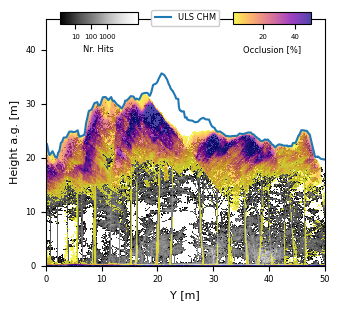

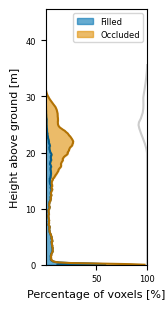

In [9]:
from occpy.visualization import get_Occl_TransectFigure_BinaryOcclusion, get_Occlusion_ProfileFigure

# define figure properties
fig_prop = dict(fig_size=(3.5, 3.2),
                label_size=8,
                label_size_ticks=6,
                label_size_tiny=5,
                out_format='png',)

# get transect figure
%matplotlib inline
get_Occl_TransectFigure_BinaryOcclusion(Nhit_norm, Classification_norm, plot_dim=config['plot_dim'], vox_dim=config['vox_dim'],
                                        out_dir=config['out_dir'], axis=0, start_ind=0, end_ind=100, chm=chm, vertBuffer=10, fig_prop=fig_prop, show_plots=True)
# define figure properties for occlusion profile
fig_prop = dict(fig_size=(1.75, 3.2),
                label_size=8,
                label_size_ticks=6,
                label_size_tiny=5,
                out_format='png', )
get_Occlusion_ProfileFigure(Classification_norm, plot_dim=config['plot_dim'], vox_dim=config['vox_dim'], out_dir=config['out_dir'], low_thresh=0, vertBuffer=10, max_percentage=100, fig_prop=fig_prop, show_plots=True)
